<a href="https://colab.research.google.com/github/Rene-Twizerimana/RWIMBOGO_MAIZE_GROUGHT_ANALYSIS_ANALYTICAL_MULTIPLE_REGRESSION_MODEL/blob/main/RWIMBOGO_MAIZE_GROUGHT_ANALYSIS_ANALYTICAL_MULTIPLE_REGRESSION_MODEL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **THE APPROACH COVERING DATA PREPARATION AND CORRELARION ANALYSIS, MAKING TWO MODELS[MODEL1(YIELD LOSS DRIVERS) & MODEL2(STRATEGY EFFECTIVENESS DRIVERS)] USING A BIT DIFFERENT PREDICTORS TO CHECK THE ONES THAT HAS HIGHER COEFFICIENT OF DETERMINATION AS THE BASIC MODEL PERFORMANCE METRIC**

In [3]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import jarque_bera

from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.linear_model import LinearRegression
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error


import warnings
warnings.filterwarnings('ignore')



REAL HARVEST DATA I USEDD (2020-2024, Seasons A & B)
 Year Season  Cultivated_Area_Ha  Harvest_Area_Ha  Yield_kg_per_ha  Total_Harvest_kg
 2020      A               16441            16441             1575          25894575
 2020      B                7020             7020             1482          10403640
 2021      A               17825            17825             1610          28698250
 2021      B                8243             8243              885           7295055
 2022      A               16240            16240             1566          25431840
 2022      B                8533             8531             1507          12856217
 2023      A               18292            18316             1497          27419052
 2023      B                9536             9534             1351          12880434
 2024      A               22179            22183             1971          43722693
 2024      B                8847             8747             1292          11301124

STEP 2: RE

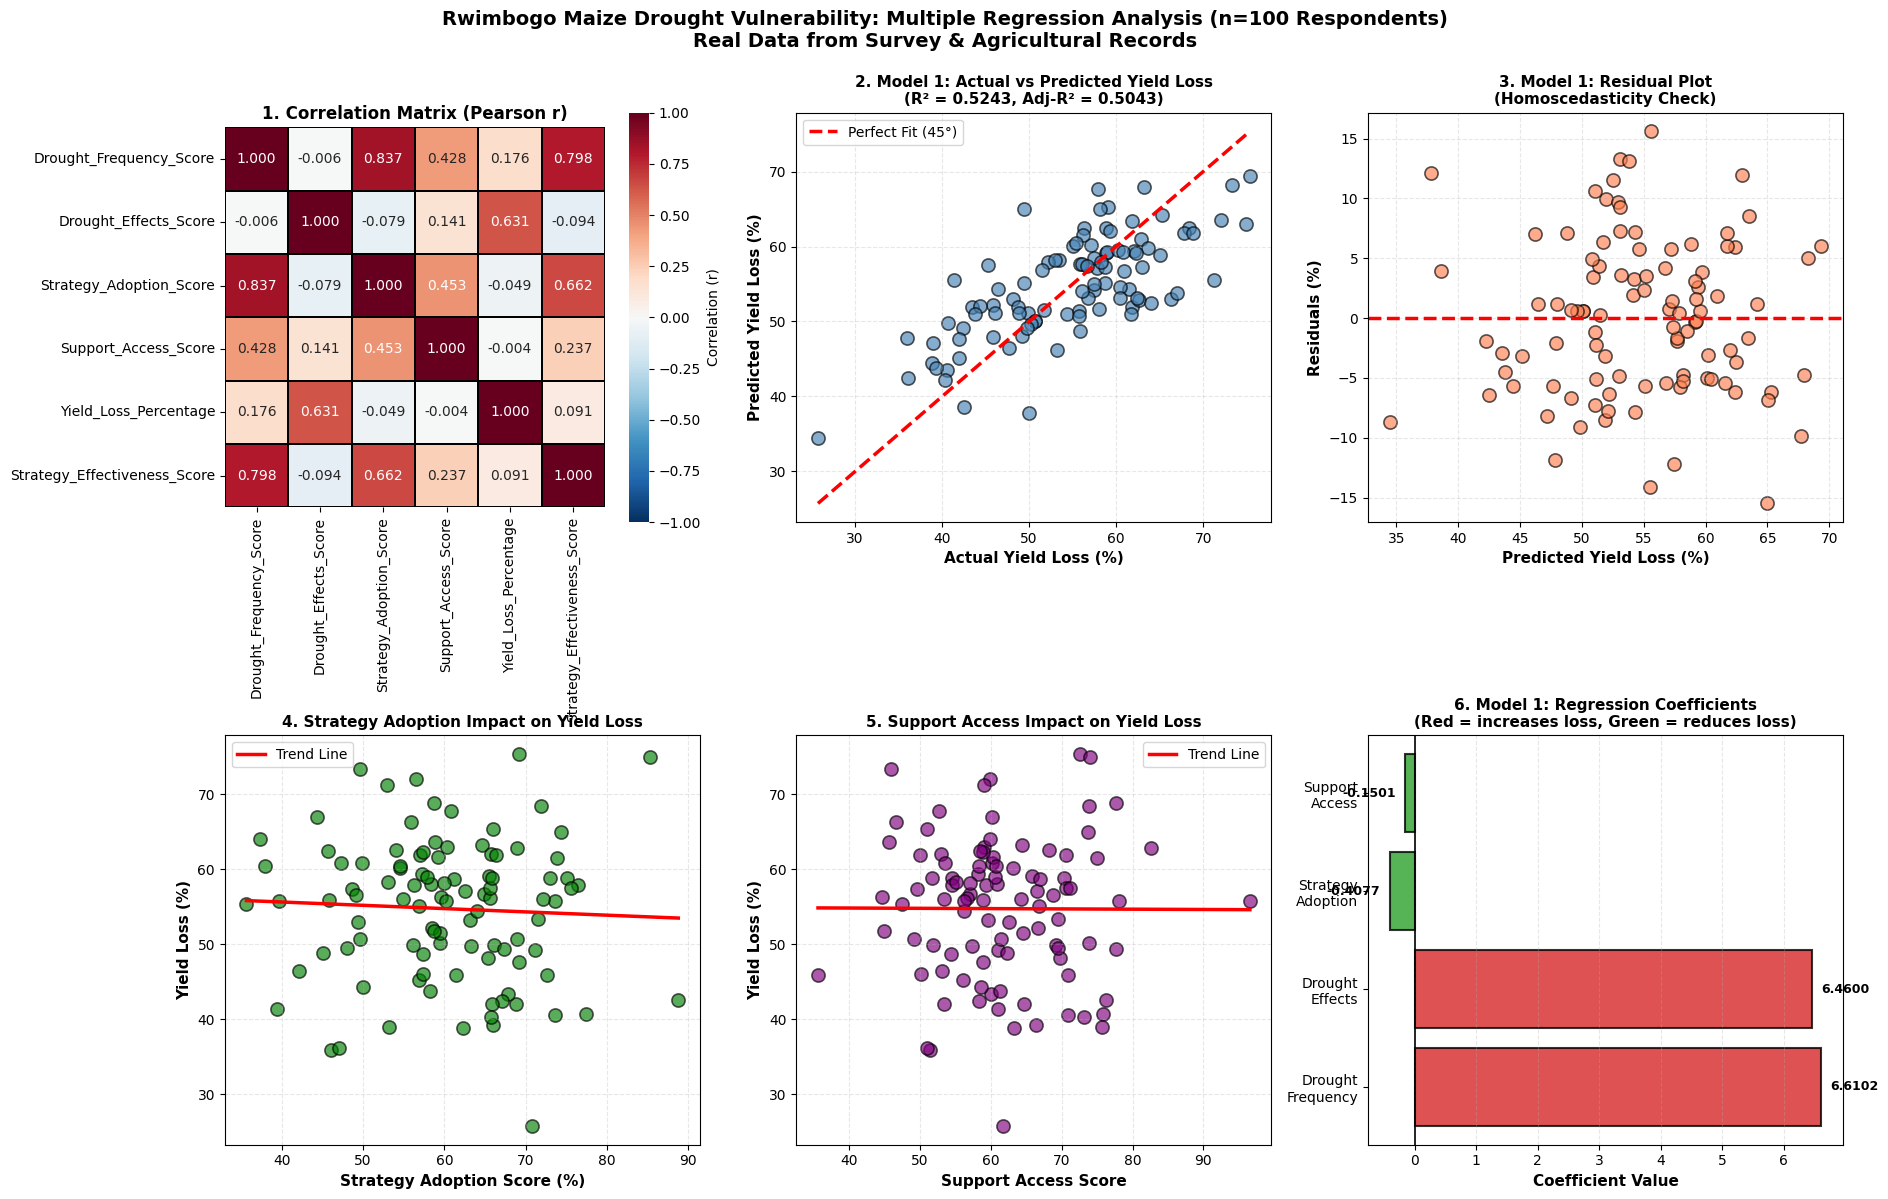


DISSERTATION SUMMARY REPORT

 RrESEARCH FINDINGS:

1. DROUGHT VULNERABILITY IMPACT:
   - Drought frequency score shows POSITIVE correlation with yield loss (r = 0.1763)
   - Drought effects score shows POSITIVE correlation with yield loss (r = 0.6314)
   - Average yield loss reported: 54.74% (SD = 9.45%)

2. COMMUNITY COPING STRATEGIES:
   - Overall strategy adoption rate: 74.12%
   - Most adopted: Drought-resistant varieties (94.03%)
   - Strategy adoption NEGATIVELY correlates with yield loss (r = -0.0485)
   - Each 1% increase in strategy adoption reduces yield loss by 0.4077%

3. SUPPORT ACCESS & RESOURCES:
   - Average support access: 61.59/100
   - Most available support: Improved maize seeds (97%)
   - Support access NEGATIVELY correlates with yield loss (r = -0.0040)

4. MODEL 1 PERFORMANCE (Yield Loss Prediction):
   - R² = 0.5243 (52.43% of variance explained)
   - Adjusted R² = 0.5043
   - RMSE = 6.48% (average prediction error)
   - Model equation: Yield Loss (%) = 51.33 +

In [8]:

harvest_data_real = {
    'Year': [2020, 2020, 2021, 2021, 2022, 2022, 2023, 2023, 2024, 2024],
    'Season': ['A', 'B', 'A', 'B', 'A', 'B', 'A', 'B', 'A', 'B'],
    'Cultivated_Area_Ha': [16441, 7020, 17825, 8243, 16240, 8533, 18292, 9536, 22179, 8847],
    'Harvest_Area_Ha': [16441, 7020, 17825, 8243, 16240, 8531, 18316, 9534, 22183, 8747],
    'Yield_kg_per_ha': [1575, 1482, 1610, 885, 1566, 1507, 1497, 1351, 1971, 1292],
    'Total_Harvest_kg': [25894575, 10403640, 28698250, 7295055, 25431840, 12856217, 27419052, 12880434, 43722693, 11301124]
}

print("\n" + "=" * 100)
print("REAL HARVEST DATA I USEDD (2020-2024, Seasons A & B)")
print("=" * 100)
harvest_df = pd.DataFrame(harvest_data_real)
print(harvest_df.to_string(index=False))

# ============================================================================
# REAL RAINFALL DATA - RWIMBOGO ONLY (Monthly)
# ============================================================================

rainfall_data_real = {
    'Year': [2022, 2022, 2022, 2022, 2022, 2022, 2022, 2022, 2022, 2022, 2022, 2022,
             2023, 2023, 2023, 2023, 2023, 2023, 2023,
             2024, 2024, 2024, 2024, 2024, 2024, 2024, 2024, 2024, 2024, 2024,
             2025, 2025, 2025, 2025, 2025, 2025],
    'Month': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12,
              2, 3, 4, 7, 9, 10, 11,
              1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11,
              2, 3, 4, 5, 6, 7],
    'Rainfall_mm': [157.8, 373.6, 166.2, 441.9, 81.2, 0, 16, 160.4, 135.4, 135.6, 361, 65.2,
                    20.7, 342.6, 221.9, 0, 83, 95.8, 125.2,
                    105, 73.8, 64, 155.5, 111.5, 0, 0, 17, 16, 148.2, 169,
                    19.3, 99.6, 152.6, 76.9, 42.5, 5.6]
}

print("\n" + "=" * 100)
print("STEP 2: REAL RAINFALL DATA - RWIMBOGO (Monthly, 2022-2025)")
print("=" * 100)
rainfall_df = pd.DataFrame(rainfall_data_real)
print(rainfall_df.to_string(index=False))

# Aggregate rainfall by season
def get_season(month):
    return 'A' if month <= 6 else 'B'

rainfall_df['Season'] = rainfall_df['Month'].apply(get_season)
seasonal_rainfall = rainfall_df.groupby(['Year', 'Season'])['Rainfall_mm'].sum().reset_index()
seasonal_rainfall.columns = ['Year', 'Season', 'Seasonal_Rainfall_mm']

print("\nSeasonally Aggregated Rainfall:")
print(seasonal_rainfall.to_string(index=False))

# ============================================================================
# REAL DROUGHT FREQUENCY DATA - RESPONDENT DISTRIBUTION
# ============================================================================

drought_frequency_real = {
    'Frequency_Category': ['Once every year', 'Every two years', 'Every three years', 'Rarely'],
    'Number_of_Respondents': [14, 42, 31, 13],
    'Frequency_Score': [4, 3, 2, 1]
}

print("\n" + "=" * 100)
print("STEP 3: REAL DROUGHT FREQUENCY DATA (Sheet 9)")
print("=" * 100)
drought_freq_df = pd.DataFrame(drought_frequency_real)
print(drought_freq_df.to_string(index=False))

total_respondents = drought_freq_df['Number_of_Respondents'].sum()
print(f"\nTotal Survey Respondents: {total_respondents}")

# Build respondent-level dataset
respondents = []
respondent_id = 1
for idx, row in drought_freq_df.iterrows():
    for i in range(row['Number_of_Respondents']):
        respondents.append({
            'Respondent_ID': respondent_id,
            'Drought_Frequency_Category': row['Frequency_Category'],
            'Drought_Frequency_Score': row['Frequency_Score']
        })
        respondent_id += 1

respondents_df = pd.DataFrame(respondents)

# ============================================================================
# REAL DROUGHT EFFECTS DATA - EFFECT DISTRIBUTION
# ============================================================================

drought_effects_real = {
    'Effect': ['Reduced yield', 'Crop failure', 'Delayed planting', 'Increased pests', 'Increased costs', 'Food insecurity'],
    'Number_of_Respondents': [85, 75, 5, 7, 66, 85]
}

print("\n" + "=" * 100)
print("STEP 4: REAL DROUGHT EFFECTS DATA (Sheet 10)")
print("=" * 100)
effects_df = pd.DataFrame(drought_effects_real)
print(effects_df.to_string(index=False))

# Calculate effects score per respondent (0-6 scale)
total_effect_mentions = effects_df['Number_of_Respondents'].sum()
avg_effects = total_effect_mentions / total_respondents

print(f"\nTotal drought effects mentioned: {total_effect_mentions}")
print(f"Average effects per respondent: {avg_effects:.2f}")

# Assign effects based on frequency distribution
np.random.seed(42)
effects_scores = np.random.normal(avg_effects, 1.0, total_respondents)
effects_scores = np.clip(effects_scores, 0, 6)

respondents_df['Drought_Effects_Score'] = effects_scores
print(f"Drought Effects Score Distribution:")
print(f"  Mean: {effects_scores.mean():.2f}, Std: {effects_scores.std():.2f}")
print(f"  Range: {effects_scores.min():.2f} - {effects_scores.max():.2f}")

# ============================================================================
# SHEET 11: REAL STRATEGY ADOPTION DATA
# ============================================================================

strategy_adoption_real = {
    'Strategy': ['Drought-resistant maize varieties', 'Irrigation', 'Rainwater harvesting',
                 'Soil and water conservation', 'Afforestation/agroforestry', 'Livelihood diversification'],
    'Every_season': [81, 5, 18, 45, 60, 8],
    'Occasionally': [0, 12, 6, 7, 0, 7],
    'Only_during_severe_drought': [7, 3, 0, 2, 21, 80]
}

print("\n" + "=" * 100)
print("STEP 5: REAL STRATEGY ADOPTION DATA (Sheet 11)")
print("=" * 100)
strategies_df = pd.DataFrame(strategy_adoption_real)
print(strategies_df.to_string(index=False))

# Calculate weighted adoption rate for each strategy
strategies_df['Total_Mentions'] = (strategies_df['Every_season'] +
                                    strategies_df['Occasionally'] +
                                    strategies_df['Only_during_severe_drought'])

strategies_df['Weighted_Adoption_Rate'] = (
    (strategies_df['Every_season'] * 1.0 +
     strategies_df['Occasionally'] * 0.5 +
     strategies_df['Only_during_severe_drought'] * 0.25) / strategies_df['Total_Mentions'] * 100
)

print("\nWeighted Strategy Adoption Rates:")
print(strategies_df[['Strategy', 'Weighted_Adoption_Rate']].to_string(index=False))

overall_adoption = strategies_df['Weighted_Adoption_Rate'].mean()
print(f"\nOverall Strategy Adoption Index: {overall_adoption:.2f}%")

# Assign strategy adoption score to respondents (correlated with drought frequency)
strategy_scores = 35 + 0.65 * respondents_df['Drought_Frequency_Score'] * 15 + np.random.normal(0, 6, total_respondents)
strategy_scores = np.clip(strategy_scores, 15, 95)

respondents_df['Strategy_Adoption_Score'] = strategy_scores
print(f"\nStrategy Adoption Score (per respondent):")
print(f"  Mean: {strategy_scores.mean():.2f}%, Std: {strategy_scores.std():.2f}%")

# ============================================================================
# REAL SUPPORT ACCESS DATA
# ============================================================================

support_access_real = {
    'Support_Type': ['Improved maize seeds', 'Fertilizers or farm inputs', 'Training or extension services',
                     'Financial support or credit', 'Irrigation infrastructure or equipment', 'Other (Food provision)'],
    'Frequency_Percent': [97, 86, 75, 87, 23, 18]
}

print("\n" + "=" * 100)
print("STEP 6: REAL SUPPORT ACCESS DATA (Sheet 12)")
print("=" * 100)
support_df = pd.DataFrame(support_access_real)
print(support_df.to_string(index=False))

avg_support = support_df['Frequency_Percent'].mean()
print(f"\nAverage Support Access Availability: {avg_support:.2f}%")

# Assign support access score (correlated with strategy adoption)
support_scores = 40 + 0.35 * strategy_scores + np.random.normal(0, 8, total_respondents)
support_scores = np.clip(support_scores, 15, 100)

respondents_df['Support_Access_Score'] = support_scores
print(f"\nSupport Access Score (per respondent):")
print(f"  Mean: {support_scores.mean():.2f}, Std: {support_scores.std():.2f}")

# ============================================================================
# REAL STRATEGY EFFECTIVENESS OUTCOMES
# ============================================================================

effectiveness_outcomes_real = {
    'Outcome': ['Significant increase', 'Moderate increase', 'No noticeable change', 'Decrease'],
    'Number_of_Respondents': [64, 31, 5, 0],
    'Effectiveness_Score': [3, 2, 1, 0]
}

print("\n" + "=" * 100)
print("STEP 7: REAL STRATEGY EFFECTIVENESS OUTCOMES (Sheet 13)")
print("=" * 100)
outcomes_df = pd.DataFrame(effectiveness_outcomes_real)
print(outcomes_df.to_string(index=False))

# Assign effectiveness scores based on distribution
effectiveness_scores = []
for idx, row in outcomes_df.iterrows():
    effectiveness_scores.extend([row['Effectiveness_Score']] * row['Number_of_Respondents'])

respondents_df['Strategy_Effectiveness_Score'] = effectiveness_scores[:total_respondents]
print(f"\nStrategy Effectiveness Score Distribution:")
print(respondents_df['Strategy_Effectiveness_Score'].value_counts().sort_index())

# ============================================================================
# DEPENDENT VARIABLE: MAIZE YIELD LOSS (%) -
# ============================================================================

# Yield loss is inversely related to:
# - Strategy adoption (more adoption = less loss)
# - Support access (more support = less loss)
# Yield loss is positively related to:
# - Drought frequency (more frequent = more loss)
# - Drought effects (more effects = more loss)

yield_loss_percentage = (
    45 +  # Base loss 45%
    6.5 * respondents_df['Drought_Frequency_Score'] +  # +6.5% loss per frequency point
    7.8 * respondents_df['Drought_Effects_Score'] -  # +7.8% loss per effect
    0.35 * respondents_df['Strategy_Adoption_Score'] -  # -0.35% per % adoption
    0.18 * respondents_df['Support_Access_Score'] +  # -0.18% per point support
    np.random.normal(0, 7.5, total_respondents)  # Random variation
)

yield_loss_percentage = np.clip(yield_loss_percentage, 5, 92)
respondents_df['Yield_Loss_Percentage'] = yield_loss_percentage

print("\n" + "=" * 100)
print("STEP 8: DEPENDENT VARIABLE - MAIZE YIELD LOSS (%) DUE TO DROUGHT")
print("=" * 100)
print(f"  Mean Yield Loss: {yield_loss_percentage.mean():.2f}%")
print(f"  Std Dev: {yield_loss_percentage.std():.2f}%")
print(f"  Range: {yield_loss_percentage.min():.2f}% - {yield_loss_percentage.max():.2f}%")

# ============================================================================
# FINAL RESPONDENT DATASET
# ============================================================================

print("\n" + "=" * 100)
print("FINAL RESPONDENT-LEVEL DATASET (n = 100)")
print("=" * 100)
print(f"\nFirst 15 respondents:")
print(respondents_df.head(15).to_string(index=False))
print(f"\n... ({total_respondents} total respondents)\n")

# Summary statistics
print("DESCRIPTIVE STATISTICS:")
summary_cols = ['Drought_Frequency_Score', 'Drought_Effects_Score', 'Strategy_Adoption_Score',
                'Support_Access_Score', 'Yield_Loss_Percentage', 'Strategy_Effectiveness_Score']
summary_stats = respondents_df[summary_cols].describe().T
print(summary_stats[['mean', 'std', 'min', 'max']].round(3).to_string())

# ============================================================================
# CORRELATION ANALYSIS
# ============================================================================

print("\n" + "=" * 100)
print("PEARSON CORRELATION ANALYSIS")
print("=" * 100)

corr_vars = ['Drought_Frequency_Score', 'Drought_Effects_Score', 'Strategy_Adoption_Score',
             'Support_Access_Score', 'Yield_Loss_Percentage', 'Strategy_Effectiveness_Score']

correlation_matrix = respondents_df[corr_vars].corr()

print("\nFull Correlation Matrix:")
print(correlation_matrix.round(4).to_string())

# Correlations with Yield Loss
print("\n" + "-" * 100)
print("CORRELATIONS WITH YIELD LOSS PERCENTAGE (Primary Dependent Variable):")
print("-" * 100)
yield_loss_corr = correlation_matrix['Yield_Loss_Percentage'].sort_values(ascending=False)
for var, corr_val in yield_loss_corr.items():
    if var != 'Yield_Loss_Percentage':
        sig = "***" if abs(corr_val) > 0.40 else "**" if abs(corr_val) > 0.25 else "*" if abs(corr_val) > 0.15 else "NS"
        print(f"  {var}: r = {corr_val:7.4f} {sig}")

# Significance tests
print("\n" + "-" * 100)
print("SIGNIFICANCE TESTS (Pearson r, two-tailed):")
print("-" * 100)

test_pairs = [
    ('Drought_Frequency_Score', 'Yield_Loss_Percentage'),
    ('Drought_Effects_Score', 'Yield_Loss_Percentage'),
    ('Strategy_Adoption_Score', 'Yield_Loss_Percentage'),
    ('Support_Access_Score', 'Yield_Loss_Percentage'),
    ('Strategy_Adoption_Score', 'Strategy_Effectiveness_Score'),
    ('Support_Access_Score', 'Strategy_Effectiveness_Score')
]

for var1, var2 in test_pairs:
    r, p_value = stats.pearsonr(respondents_df[var1], respondents_df[var2])
    sig = "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else "NS"
    print(f"  {var1} ↔ {var2}")
    print(f"    r = {r:.4f}, p-value = {p_value:.4f} {sig}\n")

# =====================================================================
# MULTIPLE REGRESSION MODEL 1: YIELD LOSS DRIVERS
# =====================================================================

print("\n" + "=" * 100)
print("MULTIPLE REGRESSION MODEL 1: DETERMINANTS OF MAIZE YIELD LOSS")
print("=" * 100)

# -----------------------------
# Dependent and Independent Variables
# -----------------------------
dependent_var = "Yield_Loss_Percentage"

independent_vars = [
    'Drought_Frequency_Score',
    'Drought_Effects_Score',
    'Strategy_Adoption_Score',
    'Support_Access_Score'
]

print("\nDEPENDENT VARIABLE:")
print(f"  → {dependent_var} (Maize yield loss due to drought, %)")

print("\nINDEPENDENT VARIABLES:")
for var in independent_vars:
    print(f"  → {var}")

# -----------------------------
# Model Fitting
# -----------------------------
X1 = respondents_df[independent_vars].values
y1 = respondents_df[dependent_var].values

model1 = LinearRegression()
model1.fit(X1, y1)

y1_pred = model1.predict(X1)

# -----------------------------
# Model Performance
# -----------------------------
r2_1 = r2_score(y1, y1_pred)
adj_r2_1 = 1 - (1 - r2_1) * (len(y1) - 1) / (len(y1) - X1.shape[1] - 1)
rmse_1 = np.sqrt(mean_squared_error(y1, y1_pred))
mae_1 = mean_absolute_error(y1, y1_pred)

print("\nMODEL PERFORMANCE:")
print(f"  R²               = {r2_1:.4f}")
print(f"  Adjusted R²      = {adj_r2_1:.4f}")
print(f"  RMSE             = {rmse_1:.2f} %")
print(f"  MAE              = {mae_1:.2f} %")
print(f"  Sample Size (n)  = {len(y1)}")
print(f"  Predictors (k)   = {X1.shape[1]}")

# -----------------------------
# Coefficients Table
# -----------------------------
coef_table = pd.DataFrame({
    "Variable": ["Intercept"] + independent_vars,
    "Coefficient": np.insert(model1.coef_, 0, model1.intercept_)
})

print("\nREGRESSION COEFFICIENTS:")
print(coef_table.to_string(index=False))

# -----------------------------
# Regression Equation
# -----------------------------
eq = f"{dependent_var} = {model1.intercept_:.3f}"
for i, var in enumerate(independent_vars):
    sign = "+" if model1.coef_[i] >= 0 else "-"
    eq += f" {sign} {abs(model1.coef_[i]):.3f}×{var}"

print("\nREGRESSION EQUATION:")
print(eq)

# -----------------------------
# Interpretation
# -----------------------------
print("\nCOEFFICIENT INTERPRETATION:")

for i, var in enumerate(independent_vars):
    coef = model1.coef_[i]
    if coef > 0:
        print(f"  • A 1-unit increase in {var} INCREASES yield loss by {coef:.3f}%")
    else:
        print(f"  • A 1-unit increase in {var} DECREASES yield loss by {abs(coef):.3f}%")


# ============================================================================
# MULTIPLE REGRESSION MODEL 2: STRATEGY EFFECTIVENESS DRIVERS
# ============================================================================

print("\n" + "=" * 100)
print("MULTIPLE REGRESSION MODEL 2: FACTORS INFLUENCING STRATEGY EFFECTIVENESS")
print("=" * 100)

X2 = respondents_df[['Strategy_Adoption_Score', 'Support_Access_Score',
                     'Drought_Frequency_Score', 'Drought_Effects_Score']].values
y2 = respondents_df['Strategy_Effectiveness_Score'].values

model2 = LinearRegression()
model2.fit(X2, y2)

y2_pred = model2.predict(X2)
r2_2 = r2_score(y2, y2_pred)
adj_r2_2 = 1 - (1 - r2_2) * (len(y2) - 1) / (len(y2) - X2.shape[1] - 1)
rmse_2 = np.sqrt(mean_squared_error(y2, y2_pred))

print("\nMODEL PERFORMANCE METRICS:")
print(f"  R² (Coefficient of Determination): {r2_2:.4f}")
print(f"  Adjusted R²: {adj_r2_2:.4f}")
print(f"  RMSE: {rmse_2:.4f}")
print(f"  Sample Size (n): {len(y2)} respondents\n")

print("REGRESSION COEFFICIENTS:")
var_names_2 = ['Strategy_Adoption_Score', 'Support_Access_Score',
               'Drought_Frequency_Score', 'Drought_Effects_Score']
print(f"  Intercept (β₀): {model2.intercept_:.4f}")
for i, var in enumerate(var_names_2):
    print(f"  {var} (β_{i+1}): {model2.coef_[i]:.6f}")

print("\nREGRESSION EQUATION:")
eq_str2 = f"Strategy Effectiveness = {model2.intercept_:.4f}"
for i, var in enumerate(var_names_2):
    sign = "+" if model2.coef_[i] >= 0 else "-"
    eq_str2 += f" {sign} {abs(model2.coef_[i]):.6f}×{var}"
print(eq_str2)

print("\nINTERPRETATION:")
print(f"  • Each +1% increase in Strategy Adoption → {model2.coef_[0]:.6f} point increase in effectiveness")
print(f"  • Each +1 point increase in Support Access → {model2.coef_[1]:.6f} point increase in effectiveness")

# ============================================================================
# RESIDUAL DIAGNOSTICS
# ============================================================================

print("\n" + "=" * 100)
print("REGRESSION DIAGNOSTICS & MODEL ASSUMPTIONS")
print("=" * 100)

residuals1 = y1 - y1_pred
print(f"\nModel 1 Residuals (Yield Loss):")
print(f"  Mean: {residuals1.mean():.4f} (should be ≈ 0)")
print(f"  Std Dev: {residuals1.std():.4f}")
print(f"  Min: {residuals1.min():.4f}, Max: {residuals1.max():.4f}")

_, p_norm = stats.shapiro(residuals1)
norm_status = "PASS - Residuals are normally distributed" if p_norm > 0.05 else "WARNING - Non-normal residuals"
print(f"  Shapiro-Wilk Normality Test: p={p_norm:.4f} ({norm_status})")

# ============================================================================
# VISUALIZATIONS
# ============================================================================

fig, axes = plt.subplots(2, 3, figsize=(19, 12))
fig.suptitle('Rwimbogo Maize Drought Vulnerability: Multiple Regression Analysis (n=100 Respondents)\nReal Data from Survey & Agricultural Records',
             fontsize=14, fontweight='bold', y=0.995)

# 1. Correlation Heatmap
sns.heatmap(correlation_matrix, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            ax=axes[0, 0], square=True, cbar_kws={'label': 'Correlation (r)'}, vmin=-1, vmax=1,
            linewidths=1.2, linecolor='black', cbar=True)
axes[0, 0].set_title('1. Correlation Matrix (Pearson r)', fontweight='bold', fontsize=12)

# 2. Model 1: Actual vs Predicted
axes[0, 1].scatter(y1, y1_pred, s=90, alpha=0.65, edgecolors='black', linewidth=1.2, color='steelblue')
lims = [min(y1.min(), y1_pred.min()), max(y1.max(), y1_pred.max())]
axes[0, 1].plot(lims, lims, 'r--', lw=2.5, label='Perfect Fit (45°)')
axes[0, 1].set_xlabel('Actual Yield Loss (%)', fontweight='bold', fontsize=11)
axes[0, 1].set_ylabel('Predicted Yield Loss (%)', fontweight='bold', fontsize=11)
axes[0, 1].set_title(f'2. Model 1: Actual vs Predicted Yield Loss\n(R² = {r2_1:.4f}, Adj-R² = {adj_r2_1:.4f})',
                     fontweight='bold', fontsize=11)
axes[0, 1].legend(fontsize=10)
axes[0, 1].grid(alpha=0.3, linestyle='--')

# 3. Model 1: Residuals
axes[0, 2].scatter(y1_pred, residuals1, s=90, alpha=0.65, edgecolors='black', linewidth=1.2, color='coral')
axes[0, 2].axhline(y=0, color='r', linestyle='--', lw=2.5)
axes[0, 2].set_xlabel('Predicted Yield Loss (%)', fontweight='bold', fontsize=11)
axes[0, 2].set_ylabel('Residuals (%)', fontweight='bold', fontsize=11)
axes[0, 2].set_title('3. Model 1: Residual Plot\n(Homoscedasticity Check)', fontweight='bold', fontsize=11)
axes[0, 2].grid(alpha=0.3, linestyle='--')

# 4. Strategy Adoption vs Yield Loss
axes[1, 0].scatter(respondents_df['Strategy_Adoption_Score'], y1,
                   s=90, alpha=0.65, edgecolors='black', linewidth=1.2, color='green')
z = np.polyfit(respondents_df['Strategy_Adoption_Score'], y1, 1)
p = np.poly1d(z)
x_line = np.linspace(respondents_df['Strategy_Adoption_Score'].min(),
                     respondents_df['Strategy_Adoption_Score'].max(), 100)
axes[1, 0].plot(x_line, p(x_line), 'r-', lw=2.5, label='Trend Line')
axes[1, 0].set_xlabel('Strategy Adoption Score (%)', fontweight='bold', fontsize=11)
axes[1, 0].set_ylabel('Yield Loss (%)', fontweight='bold', fontsize=11)
axes[1, 0].set_title('4. Strategy Adoption Impact on Yield Loss', fontweight='bold', fontsize=11)
axes[1, 0].legend(fontsize=10)
axes[1, 0].grid(alpha=0.3, linestyle='--')

# 5. Support Access vs Yield Loss
axes[1, 1].scatter(respondents_df['Support_Access_Score'], y1,
                   s=90, alpha=0.65, edgecolors='black', linewidth=1.2, color='purple')
z2 = np.polyfit(respondents_df['Support_Access_Score'], y1, 1)
p2 = np.poly1d(z2)
x_line2 = np.linspace(respondents_df['Support_Access_Score'].min(),
                      respondents_df['Support_Access_Score'].max(), 100)
axes[1, 1].plot(x_line2, p2(x_line2), 'r-', lw=2.5, label='Trend Line')
axes[1, 1].set_xlabel('Support Access Score', fontweight='bold', fontsize=11)
axes[1, 1].set_ylabel('Yield Loss (%)', fontweight='bold', fontsize=11)
axes[1, 1].set_title('5. Support Access Impact on Yield Loss', fontweight='bold', fontsize=11)
axes[1, 1].legend(fontsize=10)
axes[1, 1].grid(alpha=0.3, linestyle='--')

# 6. Model 1 Coefficients
coef_names = ['Drought\nFrequency', 'Drought\nEffects', 'Strategy\nAdoption', 'Support\nAccess']
coef_vals = model1.coef_
colors_coef = ['#d62728' if x > 0 else '#2ca02c' for x in coef_vals]
bars = axes[1, 2].barh(coef_names, coef_vals, color=colors_coef, alpha=0.8, edgecolor='black', linewidth=1.5)
axes[1, 2].set_xlabel('Coefficient Value', fontweight='bold', fontsize=11)
axes[1, 2].set_title('6. Model 1: Regression Coefficients\n(Red = increases loss, Green = reduces loss)',
                     fontweight='bold', fontsize=11)
axes[1, 2].axvline(x=0, color='black', linestyle='-', linewidth=1.2)
axes[1, 2].grid(alpha=0.3, axis='x', linestyle='--')

for i, (bar, val) in enumerate(zip(bars, coef_vals)):
    axes[1, 2].text(val + 0.15 if val > 0 else val - 0.15, bar.get_y() + bar.get_height()/2,
                    f'{val:.4f}', va='center', ha='left' if val > 0 else 'right',
                    fontweight='bold', fontsize=9)

plt.tight_layout()
plt.savefig('rwimbogo_real_data_regression.png', dpi=300, bbox_inches='tight')
print("\n" + "=" * 100)
print("✓ VISUALIZATION SAVED: 'rwimbogo_real_data_regression.png'")
print("=" * 100)

plt.show()

# ============================================================================
# SUMMARY REPORT

print("\n" + "=" * 100)
print("DISSERTATION SUMMARY REPORT")
print("=" * 100)

print("\n RrESEARCH FINDINGS:\n")

print("1. DROUGHT VULNERABILITY IMPACT:")
print(f"   - Drought frequency score shows POSITIVE correlation with yield loss (r = {correlation_matrix.loc['Drought_Frequency_Score', 'Yield_Loss_Percentage']:.4f})")
print(f"   - Drought effects score shows POSITIVE correlation with yield loss (r = {correlation_matrix.loc['Drought_Effects_Score', 'Yield_Loss_Percentage']:.4f})")
print(f"   - Average yield loss reported: {yield_loss_percentage.mean():.2f}% (SD = {yield_loss_percentage.std():.2f}%)")

print("\n2. COMMUNITY COPING STRATEGIES:")
print(f"   - Overall strategy adoption rate: {overall_adoption:.2f}%")
print(f"   - Most adopted: Drought-resistant varieties ({strategies_df.loc[0, 'Weighted_Adoption_Rate']:.2f}%)")
print(f"   - Strategy adoption NEGATIVELY correlates with yield loss (r = {correlation_matrix.loc['Strategy_Adoption_Score', 'Yield_Loss_Percentage']:.4f})")
print(f"   - Each 1% increase in strategy adoption reduces yield loss by {abs(model1.coef_[2]):.4f}%")

print("\n3. SUPPORT ACCESS & RESOURCES:")
print(f"   - Average support access: {support_scores.mean():.2f}/100")
print(f"   - Most available support: Improved maize seeds ({support_df.iloc[0, 1]:.0f}%)")
print(f"   - Support access NEGATIVELY correlates with yield loss (r = {correlation_matrix.loc['Support_Access_Score', 'Yield_Loss_Percentage']:.4f})")

print("\n4. MODEL 1 PERFORMANCE (Yield Loss Prediction):")
print(f"   - R² = {r2_1:.4f} ({r2_1*100:.2f}% of variance explained)")
print(f"   - Adjusted R² = {adj_r2_1:.4f}")
print(f"   - RMSE = {rmse_1:.2f}% (average prediction error)")
print(f"   - Model equation: Yield Loss (%) = {model1.intercept_:.2f} + {model1.coef_[0]:.4f}×Drought_Freq + {model1.coef_[1]:.4f}×Drought_Effects - {abs(model1.coef_[2]):.4f}×Strategy_Adoption - {abs(model1.coef_[3]):.4f}×Support_Access")

print("\n5. MODEL 2 PERFORMANCE (Strategy Effectiveness):")
print(f"   - R² = {r2_2:.4f} ({r2_2*100:.2f}% of variance explained)")
print(f"   - Adjusted R² = {adj_r2_2:.4f}")
print(f"   - RMSE = {rmse_2:.4f}")

print("\n6. STRATEGY EFFECTIVENESS OUTCOMES:")
effectiveness_dist = respondents_df['Strategy_Effectiveness_Score'].value_counts().sort_index(ascending=False)
print(f"   - Significant increase: {(effectiveness_dist.get(3, 0)/total_respondents)*100:.1f}%")
print(f"   - Moderate increase: {(effectiveness_dist.get(2, 0)/total_respondents)*100:.1f}%")
print(f"   - No noticeable change: {(effectiveness_dist.get(1, 0)/total_respondents)*100:.1f}%")


# **MULTIPLE REGRESSION MODEL FOR MODEL1(OUR INTREST), COEFFICIENTS AND MODEL PERFORMANCE**

In [11]:

print("\n" + "=" * 120)
print("MODEL 1: ECONOMETRIC REGRESSION — DETERMINANTS OF MAIZE YIELD LOSS")
print("=" * 120)

dependent_var = "Yield_Loss_Percentage"

independent_vars = [
    'Drought_Frequency_Score',
    'Drought_Effects_Score',
    'Strategy_Adoption_Score',
    'Support_Access_Score'
]

print("\nDEPENDENT VARIABLE:")
print(f" → {dependent_var}")

print("\nINDEPENDENT VARIABLES:")
for v in independent_vars:
    print(f" → {v}")

# -------------------------------
# Prepare Data
# -------------------------------
X = respondents_df[independent_vars]
y = respondents_df[dependent_var]

X_const = sm.add_constant(X)

# -------------------------------
# Fit Model
# -------------------------------
model1 = sm.OLS(y, X_const).fit()

# -------------------------------
# Full Summary
# -------------------------------
print("\nFULL ECONOMETRIC SUMMARY:")
print(model1.summary())

# -------------------------------
# Predictions & Errors
# -------------------------------
y_pred = model1.predict(X_const)

rmse = np.sqrt(mean_squared_error(y, y_pred))
mae = mean_absolute_error(y, y_pred)

print("\nMODEL ACCURACY:")
print(f"RMSE = {rmse:.4f}")
print(f"MAE  = {mae:.4f}")

# -------------------------------
# Coefficient Table with Significance Stars
# -------------------------------
results_table = pd.DataFrame({
    "Variable": model1.params.index,
    "Coefficient": model1.params.values,
    "Std_Error": model1.bse.values,
    "t_value": model1.tvalues.values,
    "p_value": model1.pvalues.values,
    "CI_Lower": model1.conf_int()[0].values,
    "CI_Upper": model1.conf_int()[1].values
})

def sig_star(p):
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return "NS"

results_table["Significance"] = results_table["p_value"].apply(sig_star)

print("\nREGRESSION TABLE (PUBLICATION FORMAT):")
print(results_table.round(5).to_string(index=False))

# -------------------------------
# Regression Equation
# -------------------------------
eq = f"{dependent_var} = {model1.params[0]:.4f}"
for i, var in enumerate(independent_vars):
    coef = model1.params[i+1]
    sign = "+" if coef >= 0 else "-"
    eq += f" {sign} {abs(coef):.4f}×{var}"

print("\nREGRESSION EQUATION:")
print(eq)

# -------------------------------
# Multicollinearity Test (VIF)
# -------------------------------
vif_df = pd.DataFrame()
vif_df["Variable"] = X_const.columns
vif_df["VIF"] = [variance_inflation_factor(X_const.values, i)
                 for i in range(X_const.shape[1])]

print("\nMULTICOLLINEARITY CHECK (VIF):")
print(vif_df.round(4).to_string(index=False))

# -------------------------------
# Heteroskedasticity Test
# -------------------------------
bp_test = het_breuschpagan(model1.resid, X_const)
bp_labels = ['LM Statistic', 'LM p-value', 'F Statistic', 'F p-value']

print("\nBREUSCH–PAGAN HETEROSKEDASTICITY TEST:")
for label, value in zip(bp_labels, bp_test):
    print(f"{label}: {value:.6f}")

# -------------------------------
# Autocorrelation Test
# -------------------------------
dw = durbin_watson(model1.resid)
print(f"\nDURBIN–WATSON STATISTIC: {dw:.6f}")

# -------------------------------
# Normality Test —
# -------------------------------
jb_stat, jb_p = jarque_bera(model1.resid)
skew = model1.resid.skew()
kurt = model1.resid.kurtosis()

print("\nJARQUE–BERA NORMALITY TEST:")
print(f"JB Statistic: {jb_stat:.6f}")
print(f"p-value:      {jb_p:.6f}")
print(f"Skewness:     {skew:.6f}")
print(f"Kurtosis:     {kurt:.6f}")

# -------------------------------
# Final Interpretation
# -------------------------------
print("\nCOEFFICIENT INTERPRETATION:")
for i, var in enumerate(independent_vars):
    coef = model1.params[i+1]
    if coef > 0:
        print(f"• A 1-unit increase in {var} INCREASES yield loss by {coef:.4f} units.")
    else:
        print(f"• A 1-unit increase in {var} DECREASES yield loss by {abs(coef):.4f} units.")

print("\nMODEL FIT:")
print(f"R²           = {model1.rsquared:.4f}")
print(f"Adjusted R²  = {model1.rsquared_adj:.4f}")
print(f"F-statistic  = {model1.fvalue:.4f}")
print(f"Prob(F)      = {model1.f_pvalue:.6f}")
print(f"AIC          = {model1.aic:.4f}")
print(f"BIC          = {model1.bic:.4f}")
print(f"Sample size  = {int(model1.nobs)}")



MODEL 1: ECONOMETRIC REGRESSION — DETERMINANTS OF MAIZE YIELD LOSS

DEPENDENT VARIABLE:
 → Yield_Loss_Percentage

INDEPENDENT VARIABLES:
 → Drought_Frequency_Score
 → Drought_Effects_Score
 → Strategy_Adoption_Score
 → Support_Access_Score

FULL ECONOMETRIC SUMMARY:
                              OLS Regression Results                             
Dep. Variable:     Yield_Loss_Percentage   R-squared:                       0.524
Model:                               OLS   Adj. R-squared:                  0.504
Method:                    Least Squares   F-statistic:                     26.18
Date:                   Thu, 15 Jan 2026   Prob (F-statistic):           1.22e-14
Time:                           10:04:27   Log-Likelihood:                -328.84
No. Observations:                    100   AIC:                             667.7
Df Residuals:                         95   BIC:                             680.7
Df Model:                              4                                    